=== РЕЖИМ: REGRESSION ===
Коэффициент детерминации (R^2): 0.9966
Среднеквадратичная ошибка (MSE): 0.0046

Расчет значений SHAP...


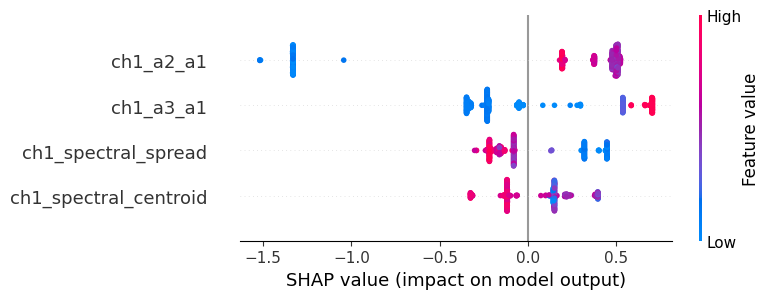

In [1]:
# c:\Users\gkb\Downloads\features_20260604_151646.xlsx
import pandas as pd

# Загружаем только столбцы с E по I
df = pd.read_excel("c:\\Users\\gkb\\Downloads\\features_20260604_151646.xlsx", usecols="E:I")

import pandas as pd
import shap
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ==========================================
# КОНСТАНТА ДЛЯ ПЕРЕКЛЮЧЕНИЯ РЕЖИМА
# Варианты: 'classification' или 'regression'
# ==========================================
TASK_TYPE = "regression"

# 1. Подготовка данных
X = df.drop(columns=["class"])
y_raw = df["class"]

# Кодируем целевую переменную в числа
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)

# 2. Разделение на train/test (80/20)
# Стратификация (stratify) возможна только для классификации
if TASK_TYPE == "classification":
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )
    # Инициализация модели классификации
    model = RandomForestClassifier(n_estimators=100, random_state=42)
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.2, random_state=42
    )
    # Инициализация модели регрессии
    model = RandomForestRegressor(n_estimators=100, random_state=42)

# 3. Обучение модели
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 4. Вывод метрик в зависимости от режима
print(f"=== РЕЖИМ: {TASK_TYPE.upper()} ===")
if TASK_TYPE == "classification":
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Точность модели (Accuracy): {accuracy:.4f}\n")
    print(classification_report(y_test, y_pred, target_names=le.classes_))
else:
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    print(f"Коэффициент детерминации (R^2): {r2:.4f}")
    print(f"Среднеквадратичная ошибка (MSE): {mse:.4f}")

# 5. Анализ SHAP
print("\nРасчет значений SHAP...")
explainer = shap.TreeExplainer(model)

if TASK_TYPE == "classification":
    # Для классификации SHAP возвращает массив для каждого класса.
    # Берем предсказания (например, для класса 1) или выводим общий summary_plot
    shap_values = explainer(X_test)
    shap.summary_plot(shap_values, X_test)
else:
    # Для регрессии SHAP возвращает одномерный массив значений
    shap_values = explainer.shap_values(X_test) if hasattr(explainer, 'shap_values') else explainer(X_test)
    # Полноценный график Beeswarm (точечный) для регрессии
    shap.summary_plot(shap_values, X_test)


In [2]:
import numpy as np
import matplotlib.pyplot as plt

def build_lifecycle(num_points: int, stage_breaks: list[str]):
    """Construct a time axis and stage assignment array."""
    k = len(stage_breaks)
    points_per_stage = num_points // k
    extra = num_points % k
    counts = [points_per_stage + (1 if i < extra else 0) for i in range(k)]
    stages = np.concatenate([np.full(c, i, dtype=int) for i, c in enumerate(counts)])
    t = np.linspace(0, 1, num_points)
    return t, stages


def stage_importance(phi: np.ndarray, stages: np.ndarray, k: int):
    """Compute stage-wise normalized importance matrix Imp[i, s]."""
    m = phi.shape[1]
    imp = np.zeros((m, k))
    for s in range(k):
        mask = stages == s
        stage_mean = phi[mask].mean(axis=0)
        numerators = np.abs(stage_mean)
        denom = np.sum(numerators)
        if denom == 0:
            continue
        imp[:, s] = numerators / denom
    return imp


def z_normalize(features: np.ndarray, stages: np.ndarray, baseline_stage: int):
    """Z-normalize using statistics from the chosen baseline stage."""
    mask = stages == baseline_stage
    mu = features[mask].mean(axis=0)
    sigma = features[mask].std(axis=0)
    sigma[sigma == 0] = 1.0
    normalized = (features - mu) / sigma
    return normalized, mu, sigma


def stage_weights(imp: np.ndarray, stage_idx: int):
    """Extract non-negative normalized weights for the chosen stage."""
    w = np.clip(imp[:, stage_idx], a_min=0.0, a_max=None)
    total = w.sum()
    if total == 0:
        return np.ones_like(w) / len(w)
    return w / total


def transform_feature(x: np.ndarray, trend: str):
    """Apply monotonic transformation depending on assumed degradation direction."""
    return x if trend == "increasing" else -x


def compute_score(normalized: np.ndarray, trend_types: list[str], weights: np.ndarray):
    """Compute raw degradation score for each time step."""
    transformed = np.stack([transform_feature(normalized[:, i], trend_types[i]) for i in range(normalized.shape[1])], axis=1)
    score = transformed @ weights
    return score


def scale_hi(score: np.ndarray, healthy_ref: float, faulty_ref: float):
    """Linearly scale score to HI in [0, 100]; higher HI = healthier."""
    hi = 100 * (score - faulty_ref) / (healthy_ref - faulty_ref)
    return np.clip(hi, 0, 100)


def ema_smooth(series: np.ndarray, alpha: float):
    smoothed = np.zeros_like(series)
    smoothed[0] = series[0]
    for i in range(1, len(series)):
        smoothed[i] = alpha * series[i] + (1 - alpha) * smoothed[i - 1]
    return smoothed


def _add_stage_bands(ax, t, stages, stage_names):
    stage_changes = np.where(np.diff(stages) != 0)[0]
    boundaries = [0] + list(stage_changes + 1) + [len(t) - 1]
    for i in range(len(boundaries) - 1):
        start = boundaries[i]
        end = boundaries[i + 1]
        ax.axvspan(t[start], t[end], color="gray", alpha=0.08 * (i % 2 == 0))


def plot_results(t, stages, phi, imp, hi_raw, hi_smooth, feature_names, stage_names, selected_features):
    fig, axes = plt.subplots(3, 1, figsize=(10, 12), constrained_layout=True)

    ax0 = axes[0]
    for idx in selected_features:
        ax0.plot(t, phi[:, idx], label=feature_names[idx])
    ax0.set_title("Динамика SHAP значений признаков")
    ax0.set_ylabel("Значение SHAP")
    ax0.set_xlabel("Нормированное время")
    ax0.legend()
    _add_stage_bands(ax0, t, stages, stage_names)

    ax1 = axes[1]
    im = ax1.imshow(imp, aspect="auto", cmap="viridis")
    ax1.set_title("Важность признаков по стадиям")
    ax1.set_ylabel("Признак")
    ax1.set_yticks(range(len(feature_names)), feature_names)
    ax1.set_xticks(range(len(stage_names)), stage_names)
    fig.colorbar(im, ax=ax1, label="Относительная важность")

    ax2 = axes[2]
    ax2.plot(t, hi_raw, label="HI", alpha=0.6)
    ax2.plot(t, hi_smooth, label="HI (сглаженный)", linewidth=2)
    ax2.set_title("HI по жизненному циклу")
    ax2.set_ylabel("HI [0-100]")
    ax2.set_xlabel("Нормированное время")
    ax2.legend()
    _add_stage_bands(ax2, t, stages, stage_names)

    plt.show()

1.1001195054768218
6.8716312563038
[0.00300382 0.25552221 0.32692072 0.41455324]


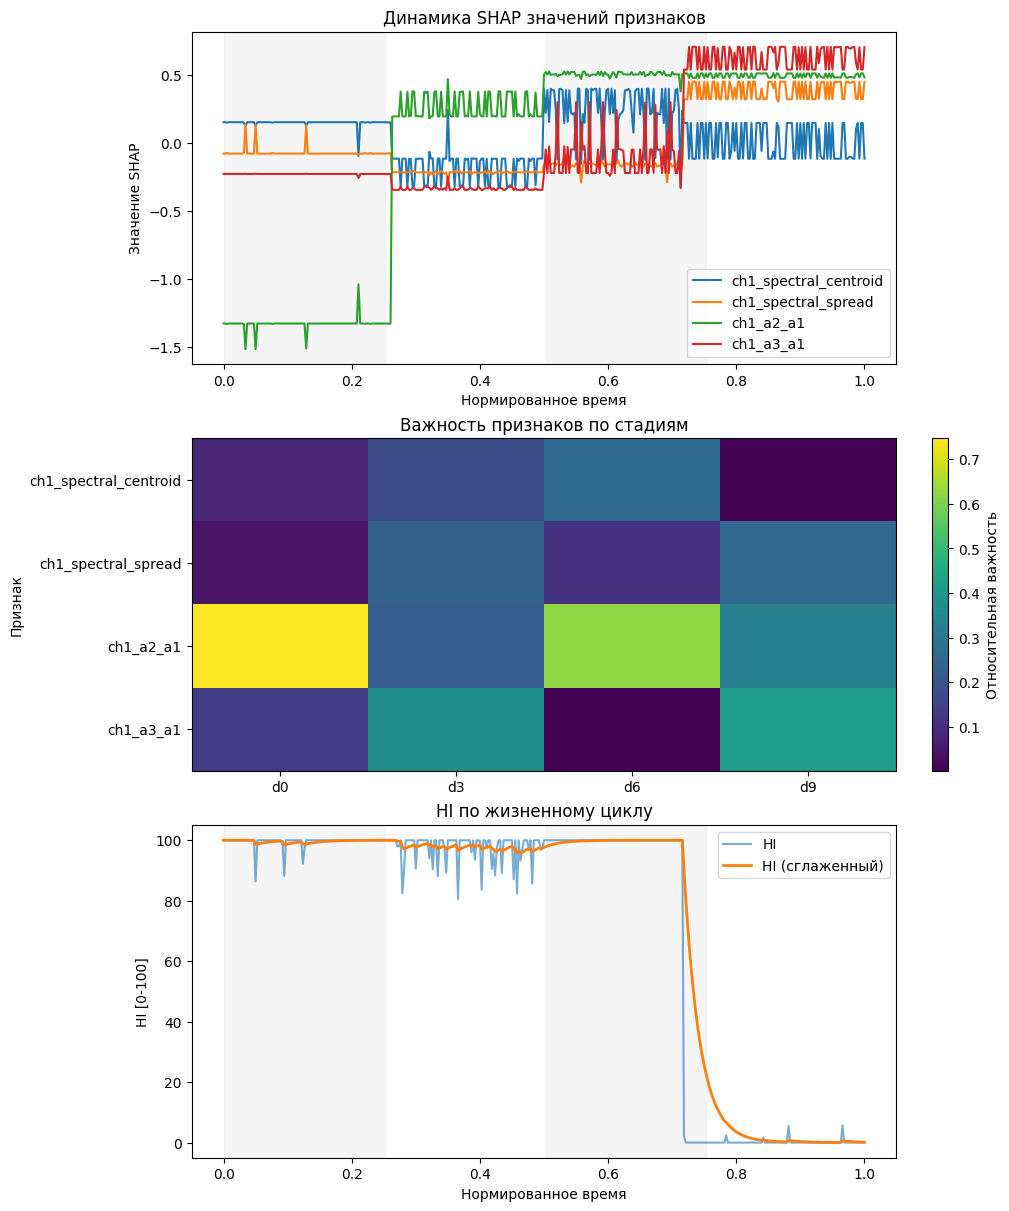

In [3]:
# Определяем тренды для признаков (это нужно сделать вручную или на основе знаний о данных)
# Пример: 'increasing' - значение со временем растет, 'decreasing' - падает
trend_types = ['decreasing', 'decreasing', 'increasing', 'increasing']

# Этапы жизненного цикла
stage_names = ["d0", "d3", "d6", "d9"]
k = len(stage_names)

# ==================================================================
# СОРТИРОВКА ДАННЫХ ПО ВРЕМЕНИ (ПО КЛАССАМ ДЕГРАДАЦИИ)
# ==================================================================
# Получаем индексы для сортировки y_test (по возрастанию классов)
sort_indices = np.argsort(y_test)

# Применяем сортировку к X_test и y_test
X_test_sorted = X_test.iloc[sort_indices]
y_test_sorted = y_test[sort_indices]


m = X_test_sorted.shape[1]
feature_names = X_test_sorted.columns.tolist()

# Создаем временную ось и этапы для тестовых данных
num_points = len(X_test_sorted)
t_vals, stages = build_lifecycle(num_points, stage_names)

# SHAP значения уже рассчитаны ранее, используем их
# Важно: `shap_values` из explainer(X_test) - это объект Explanation
# Сначала отсортируем его, а потом возьмем .values
phi_sorted = shap_values[sort_indices]

# Для классификации SHAP values имеют размерность (n_samples, n_features, n_classes)
# Усредняем абсолютное влияние по всем классам для общей важности
if hasattr(phi_sorted, 'values'):
    if len(phi_sorted.values.shape) == 3:
        phi_for_importance = np.abs(phi_sorted.values).mean(axis=2)
    else:
        phi_for_importance = phi_sorted.values
else:
    phi_for_importance = phi_sorted

# Расчет важности по стадиям
imp = stage_importance(phi_for_importance, stages, k)

# Нормализация признаков
# Используем отсортированный `X_test_sorted`
normalized, mu_base, sigma_base = z_normalize(X_test_sorted.values, stages, baseline_stage=0)

# Веса для HI из критической стадии
stage_idx_for_hi = k - 1
weights = stage_weights(imp, stage_idx_for_hi)

# Расчет "оценки деградации"
score = compute_score(normalized, trend_types, weights)

# Масштабирование в HI [0, 100]
healthy_ref = np.percentile(score[stages == 0], 95)
faulty_ref = np.percentile(score[stages == k - 1], 5)
hi_raw = scale_hi(score, healthy_ref, faulty_ref)
hi_smooth = ema_smooth(hi_raw, alpha=0.1)

# Визуализация
# Выбираем несколько признаков для отображения на графике SHAP
selected_features_indices = [0, 1, 2, 3] # Индексы признаков для визуализации

print(healthy_ref)
print(faulty_ref)
print(weights)

# Для графика динамики SHAP нам также нужны отсортированные значения
plot_results(t_vals, stages, phi_for_importance, imp, hi_raw, hi_smooth, feature_names, stage_names, selected_features_indices)